In [1]:
# Core libraries
!pip install -U pandas numpy scikit-learn

# Hugging‑Face 🤗 datasets
!pip install -U datasets

# Gradient‑boosting (choose one or both)
!pip install -U xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import os
import numpy as np
import pandas as pd
import logging
from datasets import load_dataset
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings("ignore")

In [3]:

# ----------------------------------------------------------------------
# 1. Load raw data ------------------------------------------------------
# ----------------------------------------------------------------------
def load_raw() -> pd.DataFrame:
    """
    Load the Hugging‑Face dataset and return a pandas DataFrame.
    """
    ds = load_dataset("mahmoudalyosify/SCRAP", split="train")
    df = pd.DataFrame(ds)
    # Ensure numeric dtypes (some columns may be read as objects)
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    return df


In [ ]:
data=load_raw()
data.head()

Repo card metadata block was not found. Setting CardData to empty.


,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,...,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,1.566798,5,-10.204955,-7.834756,8.602101,14923.0,13792.0,453.8,5976.6,...,0.147350,58.272095,0.004092,0.165044,0.002987,0.386462,89.0,83.0,42.0,11.0
1,0,1.207494,5,-10.355758,-7.848937,8.956374,14544.0,13792.0,474.3,5821.2,...,0.059672,57.966413,0.003753,0.164383,0.002933,0.386393,89.0,83.0,42.0,11.0
2,0,0.952193,5,-10.345631,-7.847406,8.932195,14475.0,13792.0,474.6,5796.2,...,0.039258,57.907599,0.003576,0.164352,0.002967,0.386381,89.0,83.0,42.0,11.0
3,0,0.579669,5,-10.337809,-7.845880,8.913444,14579.0,13792.0,472.7,5838.9,...,0.022066,57.993905,0.003298,0.164309,0.002918,0.386400,89.0,83.0,40.0,14.0
4,0,0.257806,5,-10.391260,-7.852942,9.036838,14510.0,13792.0,478.7,5811.1,...,0.015075,57.946717,0.003670,0.164172,0.003220,0.386388,89.0,83.0,40.0,14.0


In [4]:
# ----------------------------------------------------------------------
# 2. Filter out CDMs that would not be available at prediction time -----
# ----------------------------------------------------------------------
def filter_by_time(df: pd.DataFrame, min_days: float = 2.0) -> pd.DataFrame:
    """
    Keep only rows with time_to_tca >= min_days.
    """
    return df[df["time_to_tca"] >= min_days].copy()


In [5]:

# ----------------------------------------------------------------------
# 3. Helper: retrieve the last risk value per event (after filtering) --
# ----------------------------------------------------------------------
def _last_risk(series: pd.Series) -> float:
    """Series is already sorted chronologically → last element = final risk."""
    return series.iloc[-1]


In [6]:
# ----------------------------------------------------------------------
# 4. Aggregate time‑series statistics per event -------------------------
# ----------------------------------------------------------------------
def aggregate_event(df: pd.DataFrame) -> pd.DataFrame:
    """
    For every event_id compute mean, std, min, max of all numeric columns
    (except the target) and keep the final risk value.
    """
    # --------------------------------------------------------------
    # Columns that we want to aggregate
    # --------------------------------------------------------------
    target_col = "risk"
    numeric_cols = [
        "relative_position_r", "relative_position_t", "relative_position_n",
        "relative_velocity_r", "relative_velocity_t", "relative_velocity_n",
        "miss_distance", "relative_speed",
        "t_position_covariance_det", "c_position_covariance_det",
        "t_sigma_r", "c_sigma_r", "t_sigma_t", "c_sigma_t",
        "t_sigma_n", "c_sigma_n",
        "t_j2k_sma", "c_j2k_sma",
        "t_j2k_ecc", "c_j2k_ecc",
        "t_j2k_inc", "c_j2k_inc",
        "F10", "F3M", "SSN", "AP",
        # add any other numeric columns you care about here
    ]

    # --------------------------------------------------------------
    # Build aggregation dictionary
    # --------------------------------------------------------------
    agg_dict = {c: ["mean", "std", "min", "max"] for c in numeric_cols}
    # keep the final risk (last CDM after filtering)
    agg_dict[target_col] = [_last_risk]

    # --------------------------------------------------------------
    # Ensure chronological order so that “last” really is the most recent
    # --------------------------------------------------------------
    df = df.sort_values(["event_id", "time_to_tca"], ascending=[True, True])

    # --------------------------------------------------------------
    # Group‑by aggregation
    # --------------------------------------------------------------
    event_agg = (
        df.groupby("event_id")
        .agg(agg_dict)
        .reset_index()
    )

    # Flatten MultiIndex columns
    event_agg.columns = ["_".join(col).strip("_") for col in event_agg.columns]
    return event_agg



In [7]:
# ==============================================================================
# 5. Physics-based engineered features
# ==============================================================================
def add_physics_features(df: pd.DataFrame, df_raw: pd.DataFrame = None) -> pd.DataFrame:
    """
    Add domain-specific columns that improve model performance.
    All features are computed from the already-aggregated statistics.
    """
    # 5.1 Speed-to-Distance ratio (mean values)
    df["speed_to_distance"] = df["relative_speed_mean"] / (
        df["miss_distance_mean"] + 1e-6
    )

    # 5.2 Combined covariance determinant (target + chaser)
    df["combined_cov_det"] = (
        df["t_position_covariance_det_mean"] + df["c_position_covariance_det_mean"]
    )

    # 5.3 Orbital differences (target - chaser)
    df["delta_sma"] = df["t_j2k_sma_mean"] - df["c_j2k_sma_mean"]
    df["delta_inc"] = df["t_j2k_inc_mean"] - df["c_j2k_inc_mean"]
    df["delta_ecc"] = df["t_j2k_ecc_mean"] - df["c_j2k_ecc_mean"]

    # 5.4 Uncertainty-growth indicator (covariance determinant change)
    if df_raw is not None:
        cov_growth = (
            df_raw.sort_values(["event_id", "time_to_tca"])
            .groupby("event_id")
            .apply(
                lambda g: g["t_position_covariance_det"].iloc[-1]
                - g["t_position_covariance_det"].iloc[0]
            )
            .reset_index(name="cov_det_growth")
        )
        df = df.merge(cov_growth, on="event_id", how="left")
    else:
        df["cov_det_growth"] = 0  # Default if raw data not provided
    
    return df

In [8]:
# ----------------------------------------------------------------------
# 6. Categorical encoding (one‑hot for XGBoost, native for LightGBM) --
# ----------------------------------------------------------------------
def encode_categoricals(df: pd.DataFrame, cat_cols: List[str]) -> pd.DataFrame:
    """
    One‑hot encode the supplied categorical columns.
    The function returns a new DataFrame with the original categorical
    columns removed and the new dummy columns appended.
    """
    encoder = OneHotEncoder(sparse=False, drop="first", dtype=int)
    cat_matrix = encoder.fit_transform(df[cat_cols])

    # Build column names like c_object_type_1, mission_id_5 …
    cat_feature_names = encoder.get_feature_names_out(cat_cols)

    cat_df = pd.DataFrame(cat_matrix, columns=cat_feature_names, index=df.index)

    # Drop original categorical columns and concat the dummies
    df = df.drop(columns=cat_cols).join(cat_df)
    return df


In [9]:

# ----------------------------------------------------------------------
# 7. Log‑transform skewed numeric features -------------------------------
# ----------------------------------------------------------------------
def log_transform(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """
    Apply np.log1p to each column in `cols`.  The target column `risk` is
    **not** transformed because it is already in log10 scale.
    """
    for c in cols:
        df[c] = np.log1p(df[c])
    return df


In [10]:
# ==============================================================================
# 8. Full pipeline
# ==============================================================================
def get_preprocessed_event_table() -> pd.DataFrame:
    """
    Execute the whole preprocessing pipeline and return the final
    event-level DataFrame.
    """
    # ---- 1) Load raw -------------------------------------------------
    df_original = load_raw()

    # ---- 2) Filter CDMs that are < 2 days before TCA -----------------
    df_filtered = filter_by_time(df_original, min_days=2.0)

    # ---- 3) Aggregate per event ---------------------------------------
    event_df = aggregate_event(df_filtered)

    # ---- 4) Add physics-based engineered features ---------------------
    event_df = add_physics_features(event_df, df_original)

    # ---- 5) Encode categoricals ----------------------------------------
    # Dynamically determine the categorical columns from the aggregated dataframe
    potential_cat_cols = [col for col in event_df.columns if "_last_risk" in col and any(prefix in col for prefix in ["c_object_type", "mission_id"])]
    categorical_cols_to_encode = []
    for col in potential_cat_cols:
        # Extract original column name
        original_col_name = col.split('__')[0] if '__' in col else col.split('_')[0]
        if original_col_name in df_original.columns and df_original[original_col_name].dtype == 'object':
            categorical_cols_to_encode.append(col)

    if categorical_cols_to_encode:
        event_df = encode_categoricals(event_df, categorical_cols_to_encode)

    # ---- 6) Log-transform highly skewed numeric features -------------
    skewed_features = [
        "miss_distance_mean", "miss_distance_std",
        "relative_speed_mean", "relative_speed_std",
        "t_position_covariance_det_mean", "c_position_covariance_det_mean",
        "t_sigma_r_mean", "c_sigma_r_mean",
        "t_j2k_sma_mean", "c_j2k_sma_mean",
        "F10_mean", "AP_mean",
    ]
    skewed_features = [c for c in skewed_features if c in event_df.columns]
    event_df = log_transform(event_df, skewed_features)

    # ---- 7) Final sanity checks ---------------------------------------
    if "risk__last_risk" in event_df.columns:
        event_df = event_df.rename(columns={"risk__last_risk": "risk"})
    else:
        raise KeyError("Target column 'risk__last_risk' not found after aggregation.")

    event_df = event_df.fillna(0)

    return event_df

In [ ]:


# ----------------------------------------------------------------------
# 9. Example usage -------------------------------------------------------
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # Run the pipeline and store the result
    preprocessed = get_preprocessed_event_table()
    print("Pre‑processed shape :", preprocessed.shape)
    print("First few rows:")
    print(preprocessed.head())

    # If you want to persist the table for later modelling:
    # Create the 'data' directory if it doesn't exist
    output_dir = "data"
    os.makedirs(output_dir, exist_ok=True)
    preprocessed.to_parquet(os.path.join(output_dir, "event_level_preprocessed.parquet"), index=False)

Pre‑processed shape : (11942, 112)
First few rows:
   event_id  relative_position_r_mean  relative_position_r_std  \
0         1                 10.325000                89.664314   
1         2               -767.450000               166.266347   
2         3                 29.386667                30.199997   
3         4                174.900000                 9.959418   
4         5                -10.242857                13.694508   

   relative_position_r_min  relative_position_r_max  relative_position_t_mean  \
0                    -82.0                     99.0              -6978.200000   
1                  -1161.1                   -686.8              -5358.150000   
2                      9.8                    136.7              11155.546667   
3                    163.6                    182.4             -19276.500000   
4                    -32.0                     12.3               -374.414286   

   relative_position_t_std  relative_position_t_min  relative_pos

/tmp/ipython-input-3904939813.py:123: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [11]:
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [12]:
# ==============================================================================
# 10. Custom Loss Metric: F2-weighted MSE for High-Risk Predictions
# ==============================================================================
def compute_f2_score(y_true, y_pred, threshold=1e-6):
    """
    Compute F2-score: 5*Recall - 4*Precision emphasis on Recall.
    Classes: high-risk if y_true >= threshold, else low-risk.
    """
    y_true_binary = (y_true >= threshold).astype(int)
    y_pred_binary = (y_pred >= threshold).astype(int)
    
    tp = np.sum((y_pred_binary == 1) & (y_true_binary == 1))
    fp = np.sum((y_pred_binary == 1) & (y_true_binary == 0))
    fn = np.sum((y_pred_binary == 0) & (y_true_binary == 1))
    
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    
    f2 = (1 + 2**2) * (precision * recall) / (2**2 * precision + recall + 1e-9)
    return f2

def compound_loss(y_true, y_pred, threshold=1e-6):
    """
    Custom Compound Loss: L = (1/F2) * MSE(high_risk)
    
    Penalizes high-risk prediction errors heavily relative to low-risk.
    """
    # Compute MSE only for high-risk events (y_true >= threshold)
    high_risk_mask = y_true >= threshold
    
    if high_risk_mask.sum() == 0:
        # No high-risk events; return standard MSE
        return np.mean((y_true - y_pred) ** 2)
    
    mse_high_risk = np.mean((y_true[high_risk_mask] - y_pred[high_risk_mask]) ** 2)
    f2 = compute_f2_score(y_true, y_pred, threshold)
    
    # Avoid division by zero
    f2 = max(f2, 1e-9)
    
    loss = mse_high_risk / f2
    return loss

def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Comprehensive evaluation: MSE, MAE, R², F2-score, Compound Loss
    """
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    f2 = compute_f2_score(y_true, y_pred)
    comp_loss = compound_loss(y_true, y_pred)
    
    results = {
        "Model": model_name,
        "MSE": mse,
        "MAE": mae,
        "R²": r2,
        "F2-Score": f2,
        "Compound Loss": comp_loss
    }
    
    logger.info(f"\n{'='*60}")
    logger.info(f"Model: {model_name}")
    logger.info(f"{'='*60}")
    logger.info(f"MSE:             {mse:.6e}")
    logger.info(f"MAE:             {mae:.6e}")
    logger.info(f"R²-Score:        {r2:.6f}")
    logger.info(f"F2-Score:        {f2:.6f}")
    logger.info(f"Compound Loss:   {comp_loss:.6e}")
    logger.info(f"{'='*60}\n")
    
    return results

In [13]:
# ==============================================================================
# 11. Model Training Pipeline
# ==============================================================================
def prepare_train_test_data(df: pd.DataFrame, test_size=0.2, random_state=42):
    """
    Prepare training and testing datasets.
    - Separate target (risk) from features
    - Handle missing values and scale features
    - Return (X_train, X_test, y_train, y_test)
    """
    # Extract target and features
    if "risk" not in df.columns:
        raise ValueError("Target column 'risk' not found in DataFrame")
    
    y = df["risk"].copy()
    X = df.drop(columns=["risk", "event_id"] if "event_id" in df.columns else ["risk"])
    
    logger.info(f"Dataset shape: {X.shape}")
    logger.info(f"Target values range: [{y.min():.2e}, {y.max():.2e}]")
    logger.info(f"Missing values: {X.isnull().sum().sum()}")
    
    # Handle remaining NaNs
    X = X.fillna(0)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
    
    logger.info(f"Training set: {X_train_scaled.shape}")
    logger.info(f"Test set: {X_test_scaled.shape}")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [14]:
# ==============================================================================
# 12. Train Models: XGBoost and LightGBM
# ==============================================================================
def train_models(X_train, X_test, y_train, y_test):
    """
    Train XGBoost and LightGBM models with optimized params for this task.
    Returns both trained models and evaluation results.
    """
    try:
        import xgboost as xgb
        import lightgbm as lgb
    except ImportError as e:
        logger.error(f"Missing ML library: {e}")
        logger.info("Install with: pip install xgboost lightgbm")
        raise
    
    results_df = []
    models = {}
    
    # ========================================================================
    # XGBoost
    # ========================================================================
    logger.info("Training XGBoost model...")
    xgb_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        max_depth=7,
        learning_rate=0.05,
        n_estimators=500,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    y_pred_xgb = xgb_model.predict(X_test)
    results_xgb = evaluate_model(y_test.values, y_pred_xgb, "XGBoost")
    results_df.append(results_xgb)
    models["XGBoost"] = xgb_model
    
    # ========================================================================
    # LightGBM
    # ========================================================================
    logger.info("Training LightGBM model...")
    lgb_model = lgb.LGBMRegressor(
        objective="regression",
        max_depth=7,
        learning_rate=0.05,
        n_estimators=500,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.log_evaluation(period=0)]  # Suppress verbose output
    )
    
    y_pred_lgb = lgb_model.predict(X_test)
    results_lgb = evaluate_model(y_test.values, y_pred_lgb, "LightGBM")
    results_df.append(results_lgb)
    models["LightGBM"] = lgb_model
    
    # Create results summary
    results_summary = pd.DataFrame(results_df)
    
    logger.info("\n" + "="*60)
    logger.info("MODEL COMPARISON SUMMARY")
    logger.info("="*60)
    logger.info(results_summary.to_string(index=False))
    logger.info("="*60 + "\n")
    
    return models, results_summary, {
        "y_pred_xgb": y_pred_xgb,
        "y_pred_lgb": y_pred_lgb,
        "y_test": y_test.values
    }

In [15]:
# ==============================================================================
# 13. Feature Importance Analysis
# ==============================================================================
def plot_feature_importance(models, X_train, top_n=20):
    """
    Plot feature importance from both XGBoost and LightGBM models.
    """
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        logger.warning("matplotlib not available - skipping plots")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, (model_name, model) in enumerate(models.items()):
        importances = model.feature_importances_
        feature_names = X_train.columns
        
        # Sort and get top features
        indices = np.argsort(importances)[-top_n:]
        top_importances = importances[indices]
        top_features = feature_names[indices]
        
        # Plot
        axes[idx].barh(range(len(top_features)), top_importances, color='steelblue')
        axes[idx].set_yticks(range(len(top_features)))
        axes[idx].set_yticklabels(top_features, fontsize=9)
        axes[idx].set_xlabel("Importance Score", fontsize=11)
        axes[idx].set_title(f"{model_name} - Top {top_n} Features", fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
    logger.info("Feature importance plot saved: feature_importance.png")
    plt.show()

In [16]:
# ==============================================================================
# 14. Prediction Analysis and Visualization
# ==============================================================================
def visualize_predictions(predictions_dict):
    """
    Visualize predicted vs actual risk values and error distributions.
    """
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        logger.warning("matplotlib not available - skipping plots")
        return
    
    y_test = predictions_dict["y_test"]
    y_pred_xgb = predictions_dict["y_pred_xgb"]
    y_pred_lgb = predictions_dict["y_pred_lgb"]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # ---- XGBoost: Predicted vs Actual ----
    ax = axes[0, 0]
    ax.scatter(y_test, y_pred_xgb, alpha=0.5, s=20)
    min_val = min(y_test.min(), y_pred_xgb.min())
    max_val = max(y_test.max(), y_pred_xgb.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel("Actual Risk", fontsize=11)
    ax.set_ylabel("Predicted Risk (XGBoost)", fontsize=11)
    ax.set_title("XGBoost: Predicted vs Actual", fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # ---- LightGBM: Predicted vs Actual ----
    ax = axes[0, 1]
    ax.scatter(y_test, y_pred_lgb, alpha=0.5, s=20, color='orange')
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel("Actual Risk", fontsize=11)
    ax.set_ylabel("Predicted Risk (LightGBM)", fontsize=11)
    ax.set_title("LightGBM: Predicted vs Actual", fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # ---- XGBoost: Error Distribution (Log Scale) ----
    ax = axes[1, 0]
    error_xgb = np.abs(y_test - y_pred_xgb)
    ax.hist(np.log10(error_xgb + 1e-9), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xlabel("log₁₀(Absolute Error)", fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.set_title("XGBoost: Log Error Distribution", fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    # ---- LightGBM: Error Distribution (Log Scale) ----
    ax = axes[1, 1]
    error_lgb = np.abs(y_test - y_pred_lgb)
    ax.hist(np.log10(error_lgb + 1e-9), bins=50, color='orange', alpha=0.7, edgecolor='black')
    ax.set_xlabel("log₁₀(Absolute Error)", fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.set_title("LightGBM: Log Error Distribution", fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig("prediction_analysis.png", dpi=150, bbox_inches='tight')
    logger.info("Prediction analysis plot saved: prediction_analysis.png")
    plt.show()
    
    # Print high-risk events analysis
    threshold = 1e-6
    high_risk_actual = y_test >= threshold
    
    logger.info(f"\n{'='*60}")
    logger.info("HIGH-RISK EVENTS ANALYSIS (Risk >= 1e-6)")
    logger.info(f"{'='*60}")
    logger.info(f"Actual high-risk events: {high_risk_actual.sum()} / {len(y_test)}")
    logger.info(f"High-risk percentage: {100*high_risk_actual.sum()/len(y_test):.3f}%")
    logger.info(f"{'='*60}\n")

2026-03-01 21:28:45,674 - INFO - ================================================================================
2026-03-01 21:28:45,675 - INFO - SCRAP: SATELLITE COLLISION RISK ASSESSMENT AND PREDICTION
2026-03-01 21:28:45,676 - INFO - ================================================================================

2026-03-01 21:28:45,677 - INFO - STEP 1: Preprocessing and Feature Engineering
2026-03-01 21:28:45,678 - INFO - --------------------------------------------------------------------------------
2026-03-01 21:28:46,319 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/mahmoudalyosify/SCRAP/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-01 21:28:46,339 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/mahmoudalyosify/SCRAP/350b5307ed29ccd086a2439cfde238cf8f581c46/README.md "HTTP/1.1 200 OK"
2026-03-01 21:28:46,488 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/mahmoudalyosify/SCRAP/resolve/350b5307ed29ccd08

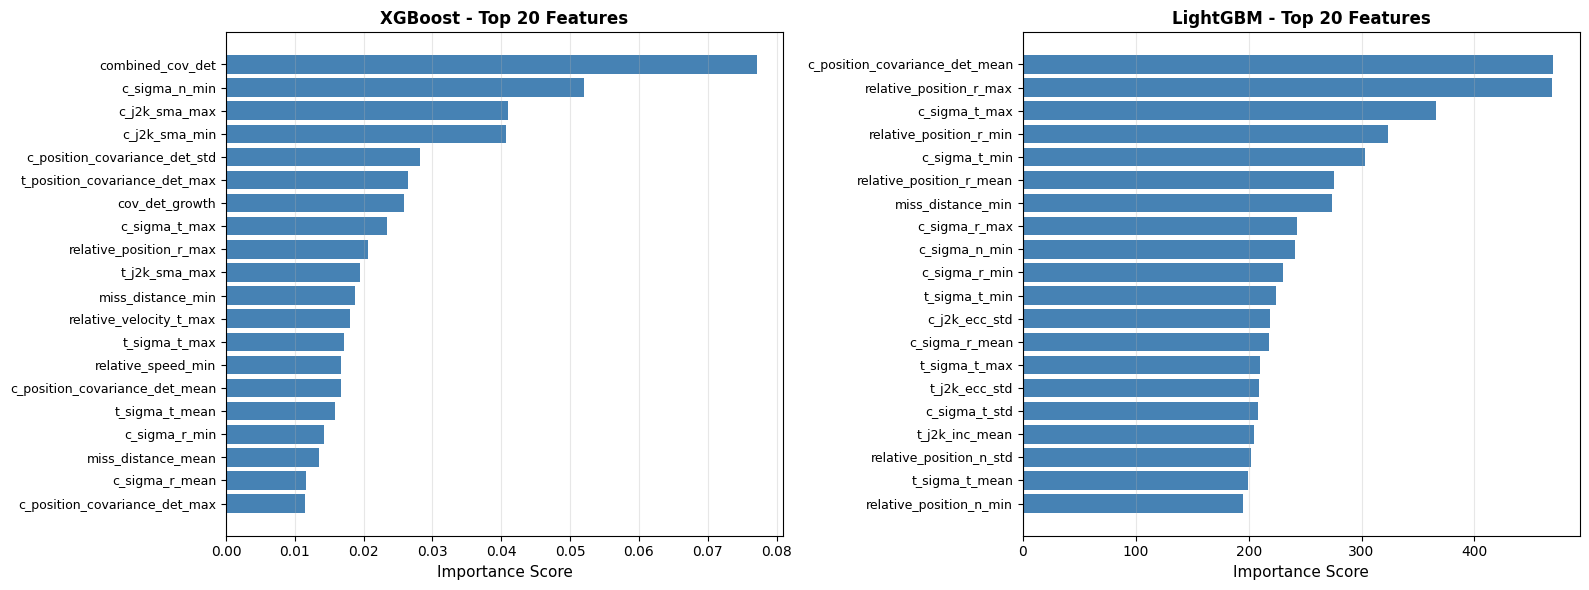

2026-03-01 21:31:47,754 - INFO - STEP 5: Prediction Analysis and Visualization
2026-03-01 21:31:47,771 - INFO - --------------------------------------------------------------------------------
2026-03-01 21:31:49,268 - INFO - Prediction analysis plot saved: prediction_analysis.png


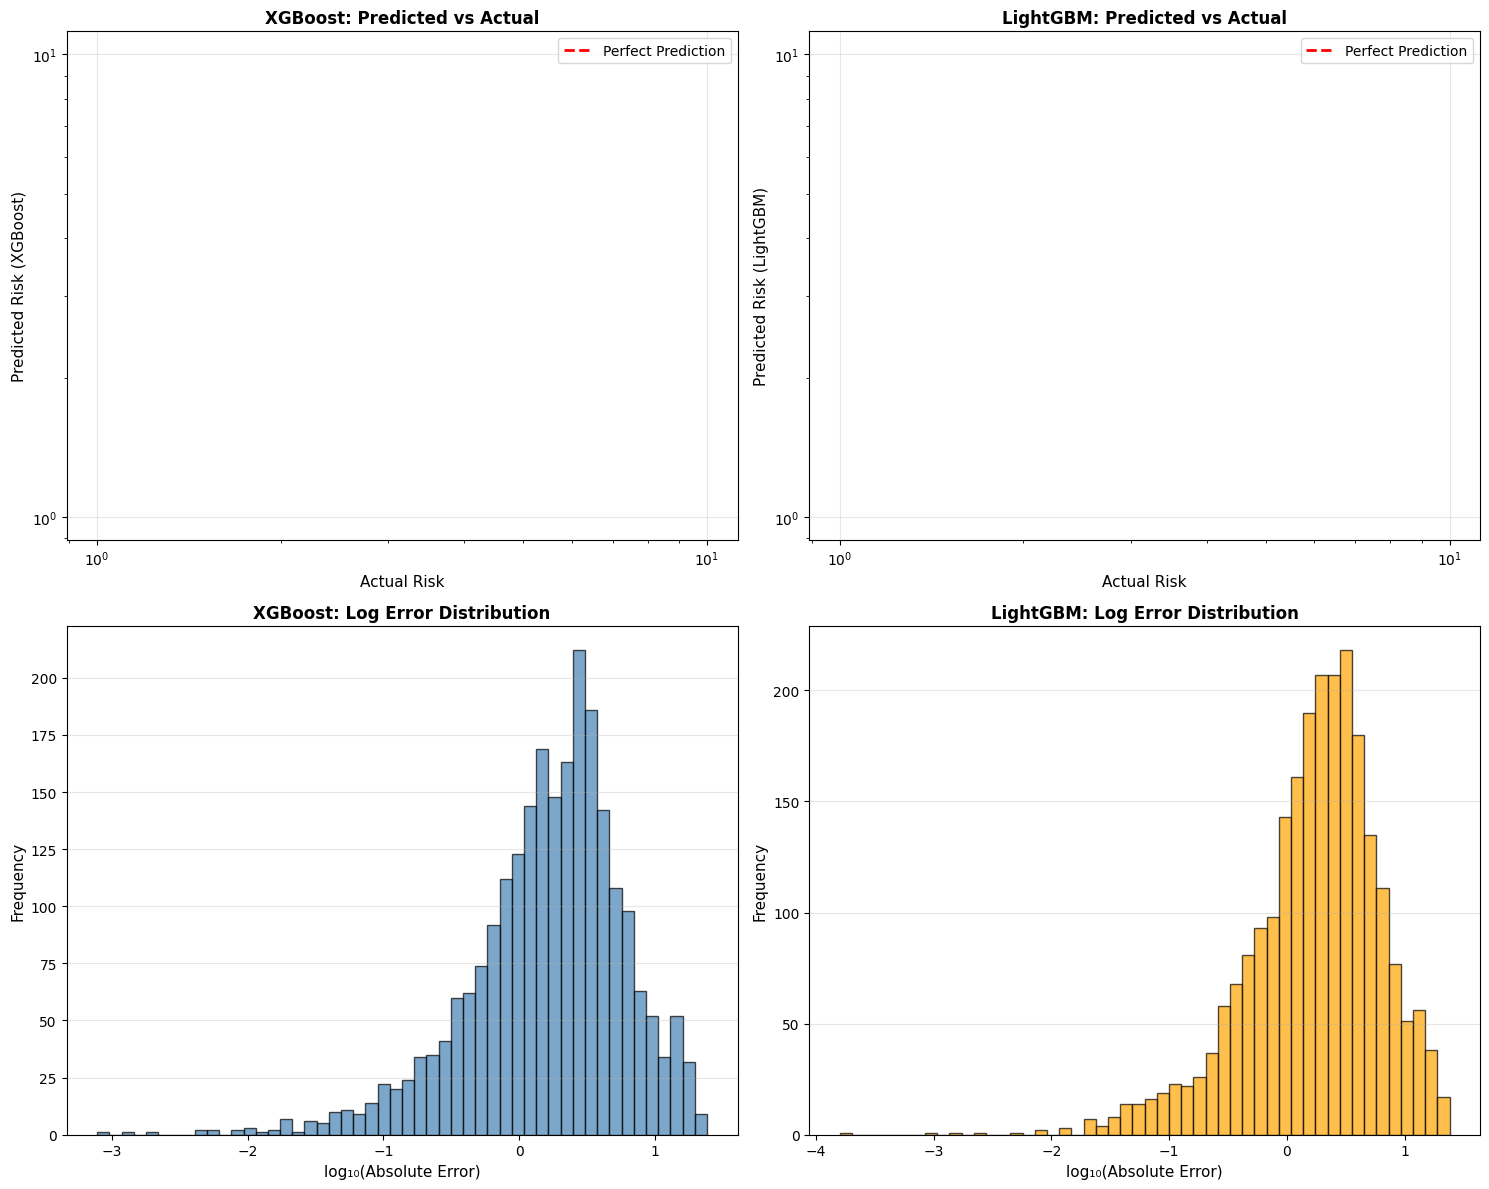

2026-03-01 21:31:49,747 - INFO - 
2026-03-01 21:31:49,748 - INFO - HIGH-RISK EVENTS ANALYSIS (Risk >= 1e-6)
2026-03-01 21:31:49,748 - INFO - ============================================================
2026-03-01 21:31:49,749 - INFO - Actual high-risk events: 0 / 2389
2026-03-01 21:31:49,749 - INFO - High-risk percentage: 0.000%
2026-03-01 21:31:49,750 - INFO - ============================================================

2026-03-01 21:31:49,750 - INFO - STEP 6: Saving Models and Results
2026-03-01 21:31:49,751 - INFO - --------------------------------------------------------------------------------
2026-03-01 21:31:50,120 - INFO - Models saved to: outputs/models.pkl
2026-03-01 21:31:50,122 - INFO - Results saved to: outputs/model_results.csv
2026-03-01 21:31:50,122 - INFO - Preprocessed data saved to: outputs/preprocessed_data.parquet
2026-03-01 21:31:50,123 - INFO - 
2026-03-01 21:31:50,124 - INFO - PIPELINE COMPLETE!
2026-03-01 21:31:50,125 - INFO - =================================

In [17]:
# ==============================================================================
# 15. MAIN EXECUTION: Complete Pipeline
# ==============================================================================
if __name__ == "__main__":
    logger.info("="*80)
    logger.info("SCRAP: SATELLITE COLLISION RISK ASSESSMENT AND PREDICTION")
    logger.info("="*80 + "\n")
    
    # ---- Step 1: Preprocess Data ----
    logger.info("STEP 1: Preprocessing and Feature Engineering")
    logger.info("-"*80)
    preprocessed_df = get_preprocessed_event_table()
    logger.info(f"Preprocessed data shape: {preprocessed_df.shape}\n")
    
    # ---- Step 2: Prepare Train/Test Split ----
    logger.info("STEP 2: Train-Test Split and Scaling")
    logger.info("-"*80)
    X_train, X_test, y_train, y_test, scaler = prepare_train_test_data(preprocessed_df)
    logger.info(f"X_train shape: {X_train.shape}")
    logger.info(f"X_test shape: {X_test.shape}\n")
    
    # ---- Step 3: Train Models ----
    logger.info("STEP 3: Model Training")
    logger.info("-"*80)
    models, results_summary, predictions_dict = train_models(X_train, X_test, y_train, y_test)
    
    # ---- Step 4: Feature Importance ----
    logger.info("STEP 4: Feature Importance Analysis")
    logger.info("-"*80)
    plot_feature_importance(models, X_train, top_n=20)
    
    # ---- Step 5: Prediction Visualization ----
    logger.info("STEP 5: Prediction Analysis and Visualization")
    logger.info("-"*80)
    visualize_predictions(predictions_dict)
    
    # ---- Step 6: Save Models and Results ----
    logger.info("STEP 6: Saving Models and Results")
    logger.info("-"*80)
    output_dir = "outputs"
    os.makedirs(output_dir, exist_ok=True)
    
    import pickle
    with open(os.path.join(output_dir, "models.pkl"), "wb") as f:
        pickle.dump(models, f)
    
    results_summary.to_csv(os.path.join(output_dir, "model_results.csv"), index=False)
    preprocessed_df.to_parquet(os.path.join(output_dir, "preprocessed_data.parquet"), index=False)
    
    logger.info(f"Models saved to: {output_dir}/models.pkl")
    logger.info(f"Results saved to: {output_dir}/model_results.csv")
    logger.info(f"Preprocessed data saved to: {output_dir}/preprocessed_data.parquet")
    
    logger.info("\n" + "="*80)
    logger.info("PIPELINE COMPLETE!")
    logger.info("="*80)

## 16. Satellite Scheduling and Visualization (Added from `My solution (1).ipynb`)

This section adds the scheduling and visualization workflow (MILP + 2D/3D views) from your solution notebook, adapted to the SCRAP dataframe used above.


In [ ]:
# Optional dependencies for this section:
# !pip install -U pulp plotly

import math
import random
import matplotlib.pyplot as plt

try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False

try:
    from pulp import (
        LpProblem,
        LpMaximize,
        LpVariable,
        LpBinary,
        lpSum,
        LpStatus,
        PULP_CBC_CMD,
        value,
    )
    HAS_PULP = True
except Exception:
    HAS_PULP = False

random.seed(42)
np.random.seed(42)


In [ ]:
def angular_sep(lat1, lon1, lat2, lon2):
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dlambda = math.radians(lon2 - lon1)
    a = (
        math.sin((phi2 - phi1) / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    )
    return 2 * math.degrees(math.asin(min(1.0, math.sqrt(a))))

def wrap_longitude(series: pd.Series) -> pd.Series:
    lon = pd.to_numeric(series, errors="coerce")
    return ((lon + 180.0) % 360.0) - 180.0

def build_satellite_positions_from_scrap(
    scrap_df: pd.DataFrame,
    num_sats: int = 24,
    time_slots: int = 6,
    random_state: int = 42,
):
    rng = np.random.default_rng(random_state)
    sat_positions = {}
    sat_ids = list(range(num_sats))

    inc_pool = pd.to_numeric(
        scrap_df.get("t_j2k_inc", pd.Series(dtype=float)), errors="coerce"
    ).dropna().to_numpy()
    if inc_pool.size == 0:
        inc_pool = rng.uniform(30, 98, size=max(num_sats, 128))

    phase_offsets = rng.uniform(0, 2 * np.pi, size=num_sats)
    for sat_idx, sat_id in enumerate(sat_ids):
        inc_rad = np.radians(float(inc_pool[sat_idx % len(inc_pool)]))
        phase = phase_offsets[sat_idx]
        for slot in range(time_slots):
            theta = (2 * np.pi * slot / time_slots) + phase
            lat = np.degrees(np.arcsin(np.sin(inc_rad) * np.sin(theta)))
            lon = ((np.degrees(theta * 1.8) + sat_idx * 15 + 180) % 360) - 180
            sat_positions[(sat_id, slot)] = {"lat": float(lat), "lon": float(lon)}

    return sat_positions, sat_ids

def build_tasks_from_scrap(
    scrap_df: pd.DataFrame,
    num_tasks: int = 40,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    if "geocentric_latitude" in scrap_df.columns:
        lat = pd.to_numeric(scrap_df["geocentric_latitude"], errors="coerce")
    elif "t_j2k_inc" in scrap_df.columns:
        lat = pd.to_numeric(scrap_df["t_j2k_inc"], errors="coerce").clip(-90, 90)
    else:
        lat = pd.Series(rng.uniform(-60, 60, size=len(scrap_df)))

    if "geocentric_longitude" in scrap_df.columns:
        lon = wrap_longitude(scrap_df["geocentric_longitude"])
    elif "relative_position_t" in scrap_df.columns:
        lon = wrap_longitude(scrap_df["relative_position_t"])
    else:
        lon = pd.Series(rng.uniform(-180, 180, size=len(scrap_df)))

    if "risk" in scrap_df.columns:
        priority_raw = pd.to_numeric(scrap_df["risk"], errors="coerce")
    else:
        priority_raw = pd.Series(rng.uniform(0.2, 1.0, size=len(scrap_df)))

    tasks = pd.DataFrame({
        "lat": lat,
        "lon": lon,
        "priority_raw": priority_raw,
    }).dropna()

    if tasks.empty:
        tasks = pd.DataFrame({
            "lat": rng.uniform(-60, 60, size=num_tasks),
            "lon": rng.uniform(-180, 180, size=num_tasks),
            "priority_raw": rng.uniform(0.2, 1.0, size=num_tasks),
        })

    n = min(num_tasks, len(tasks))
    tasks = tasks.sample(n=n, random_state=random_state).reset_index(drop=True)

    p = tasks["priority_raw"]
    span = (p.max() - p.min()) if p.max() > p.min() else 1.0
    tasks["priority"] = 1.0 + 9.0 * ((p - p.min()) / span)
    tasks["task_id"] = tasks.index.astype(int)
    return tasks[["task_id", "lat", "lon", "priority"]]

def build_eligibility(
    sat_positions: dict,
    tasks_df: pd.DataFrame,
    sat_ids: list,
    time_slots: int,
    footprint_ang_deg: float = 20.0,
) -> dict:
    eligibility = {}
    for sat in sat_ids:
        for slot in range(time_slots):
            pos = sat_positions.get((sat, slot))
            if pos is None:
                continue
            for row in tasks_df.itertuples(index=False):
                eligibility[(sat, slot, int(row.task_id))] = (
                    angular_sep(pos["lat"], pos["lon"], row.lat, row.lon) <= footprint_ang_deg
                )
    return eligibility

def simulate_unavailable_sat_slots(
    sat_ids: list,
    time_slots: int,
    anomaly_rate: float = 0.05,
    random_state: int = 42,
) -> set:
    rng = random.Random(random_state)
    unavailable = set()
    for sat in sat_ids:
        for slot in range(time_slots):
            if rng.random() < anomaly_rate:
                unavailable.add((sat, slot))
    return unavailable

def solve_schedule(
    tasks_df: pd.DataFrame,
    sat_ids: list,
    time_slots: int,
    eligibility: dict,
    unavailable: set,
) -> tuple[pd.DataFrame, object]:
    if not HAS_PULP:
        raise ImportError("PuLP is not installed. Run: pip install pulp")

    priorities = tasks_df.set_index("task_id")["priority"].to_dict()
    task_lookup = tasks_df.set_index("task_id")

    prob = LpProblem("satellite_scheduler", LpMaximize)
    x = {}
    for sat in sat_ids:
        for slot in range(time_slots):
            if (sat, slot) in unavailable:
                continue
            for tid in tasks_df["task_id"]:
                if eligibility.get((sat, slot, int(tid)), False):
                    x[(sat, slot, int(tid))] = LpVariable(
                        f"x_{sat}_{slot}_{int(tid)}",
                        lowBound=0,
                        upBound=1,
                        cat=LpBinary,
                    )

    if not x:
        raise ValueError("No feasible assignments were generated.")

    prob += lpSum(priorities[tid] * var for (_, _, tid), var in x.items())

    for tid in tasks_df["task_id"]:
        prob += lpSum(var for (s, t, k), var in x.items() if k == int(tid)) <= 1

    for sat in sat_ids:
        for slot in range(time_slots):
            prob += lpSum(var for (s, t, k), var in x.items() if s == sat and t == slot) <= 1

    prob.solve(PULP_CBC_CMD(msg=False))

    assignments = []
    for (sat, slot, tid), var in x.items():
        v = value(var)
        if v is not None and v > 0.5:
            task = task_lookup.loc[tid]
            assignments.append({
                "sat_id": sat,
                "slot": slot,
                "task_id": int(tid),
                "task_lat": float(task["lat"]),
                "task_lon": float(task["lon"]),
                "priority": float(task["priority"]),
            })

    schedule_df = pd.DataFrame(assignments)
    if not schedule_df.empty:
        schedule_df = schedule_df.sort_values(["slot", "sat_id"]).reset_index(drop=True)

    return schedule_df, prob

def plot_schedule_2d(
    tasks_df: pd.DataFrame,
    sat_positions: dict,
    sat_ids: list,
    slot_to_plot: int = 0,
    schedule_df: pd.DataFrame | None = None,
):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(tasks_df["lon"], tasks_df["lat"], marker="o", alpha=0.8, label="Tasks")

    sat_lons = [sat_positions[(s, slot_to_plot)]["lon"] for s in sat_ids if (s, slot_to_plot) in sat_positions]
    sat_lats = [sat_positions[(s, slot_to_plot)]["lat"] for s in sat_ids if (s, slot_to_plot) in sat_positions]
    ax.scatter(sat_lons, sat_lats, marker="^", s=80, color="tab:red", label=f"Satellites (slot {slot_to_plot})")

    if schedule_df is not None and not schedule_df.empty:
        task_lookup = tasks_df.set_index("task_id")
        chosen = schedule_df[schedule_df["slot"] == slot_to_plot]
        for row in chosen.itertuples(index=False):
            sp = sat_positions.get((int(row.sat_id), slot_to_plot))
            if sp is None or int(row.task_id) not in task_lookup.index:
                continue
            tp = task_lookup.loc[int(row.task_id)]
            ax.plot([sp["lon"], tp["lon"]], [sp["lat"], tp["lat"]], color="gray", alpha=0.5)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Satellite Tasking (2D Map)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    return fig

def _latlon_to_xyz(lat_deg: float, lon_deg: float, radius_km: float):
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    x = radius_km * np.cos(lat) * np.cos(lon)
    y = radius_km * np.cos(lat) * np.sin(lon)
    z = radius_km * np.sin(lat)
    return x, y, z

def plot_orbits_3d(sat_positions: dict, sat_ids: list, time_slots: int, orbit_alt_km: float = 550.0):
    if not HAS_PLOTLY:
        raise ImportError("Plotly is not installed. Run: pip install plotly")

    earth_r = 6371.0
    lats = np.linspace(-np.pi / 2, np.pi / 2, 60)
    lons = np.linspace(-np.pi, np.pi, 120)
    xs = earth_r * np.outer(np.cos(lats), np.cos(lons))
    ys = earth_r * np.outer(np.cos(lats), np.sin(lons))
    zs = earth_r * np.outer(np.sin(lats), np.ones_like(lons))

    traces = [
        go.Surface(
            x=xs,
            y=ys,
            z=zs,
            showscale=False,
            colorscale="Blues",
            opacity=0.85,
            name="Earth",
            hoverinfo="skip",
        )
    ]

    for sat in sat_ids:
        x_orbit, y_orbit, z_orbit = [], [], []
        for slot in range(time_slots):
            p = sat_positions.get((sat, slot))
            if p is None:
                continue
            x, y, z = _latlon_to_xyz(p["lat"], p["lon"], earth_r + orbit_alt_km)
            x_orbit.append(x)
            y_orbit.append(y)
            z_orbit.append(z)

        if len(x_orbit) >= 2:
            traces.append(
                go.Scatter3d(
                    x=x_orbit,
                    y=y_orbit,
                    z=z_orbit,
                    mode="lines+markers",
                    marker=dict(size=2),
                    line=dict(width=2),
                    name=f"SAT-{sat}",
                )
            )

    fig = go.Figure(data=traces)
    fig.update_layout(
        title="3D Earth: Satellite Orbit Tracks",
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            aspectmode="data",
        ),
        margin=dict(l=0, r=0, t=40, b=0),
    )
    return fig


In [ ]:
TIME_SLOTS_SCHED = 6
FOOTPRINT_ANG_DEG = 20.0

scrap_df_for_sched = data.copy() if "data" in globals() else load_raw()

sat_positions, sat_ids = build_satellite_positions_from_scrap(
    scrap_df_for_sched,
    num_sats=24,
    time_slots=TIME_SLOTS_SCHED,
    random_state=42,
)
tasks_df = build_tasks_from_scrap(scrap_df_for_sched, num_tasks=40, random_state=42)
eligibility = build_eligibility(
    sat_positions,
    tasks_df,
    sat_ids,
    time_slots=TIME_SLOTS_SCHED,
    footprint_ang_deg=FOOTPRINT_ANG_DEG,
)
unavailable = simulate_unavailable_sat_slots(
    sat_ids,
    time_slots=TIME_SLOTS_SCHED,
    anomaly_rate=0.05,
    random_state=42,
)

schedule_df, sched_prob = solve_schedule(
    tasks_df,
    sat_ids,
    time_slots=TIME_SLOTS_SCHED,
    eligibility=eligibility,
    unavailable=unavailable,
)

print(f"Solver status: {LpStatus[sched_prob.status]}")
print(f"Total tasks: {len(tasks_df)}")
print(f"Scheduled tasks: {len(schedule_df)}")
schedule_df.head(10)


In [ ]:
plot_schedule_2d(
    tasks_df=tasks_df,
    sat_positions=sat_positions,
    sat_ids=sat_ids,
    slot_to_plot=0,
    schedule_df=schedule_df,
)


In [ ]:
if HAS_PLOTLY:
    fig3d = plot_orbits_3d(
        sat_positions=sat_positions,
        sat_ids=sat_ids,
        time_slots=TIME_SLOTS_SCHED,
        orbit_alt_km=550.0,
    )
    fig3d.show()
else:
    print("Plotly not installed. Run: pip install plotly")
